Original dimensions: 1160 x 652

Rotation Matrix R:
[[ 0.8660254  0.5        0.       ]
 [-0.5        0.8660254  0.       ]
 [ 0.         0.         1.       ]]

Translation Matrix T:
[[  1.   0. 120.]
 [  0.   1.  60.]
 [  0.   0.   1.]]

Combined rigid matrix T @ R:
[[  0.8660254   0.5       120.       ]
 [ -0.5         0.8660254  60.       ]
 [  0.          0.          1.       ]]

New dimensions: 1451 x 1145

Final transformation matrix:
[[ 8.660254e-01  5.000000e-01  1.200000e+02]
 [-5.000000e-01  8.660254e-01  5.800000e+02]
 [ 0.000000e+00  0.000000e+00  1.000000e+00]]

Saved: task5_aligned_chip.jpg


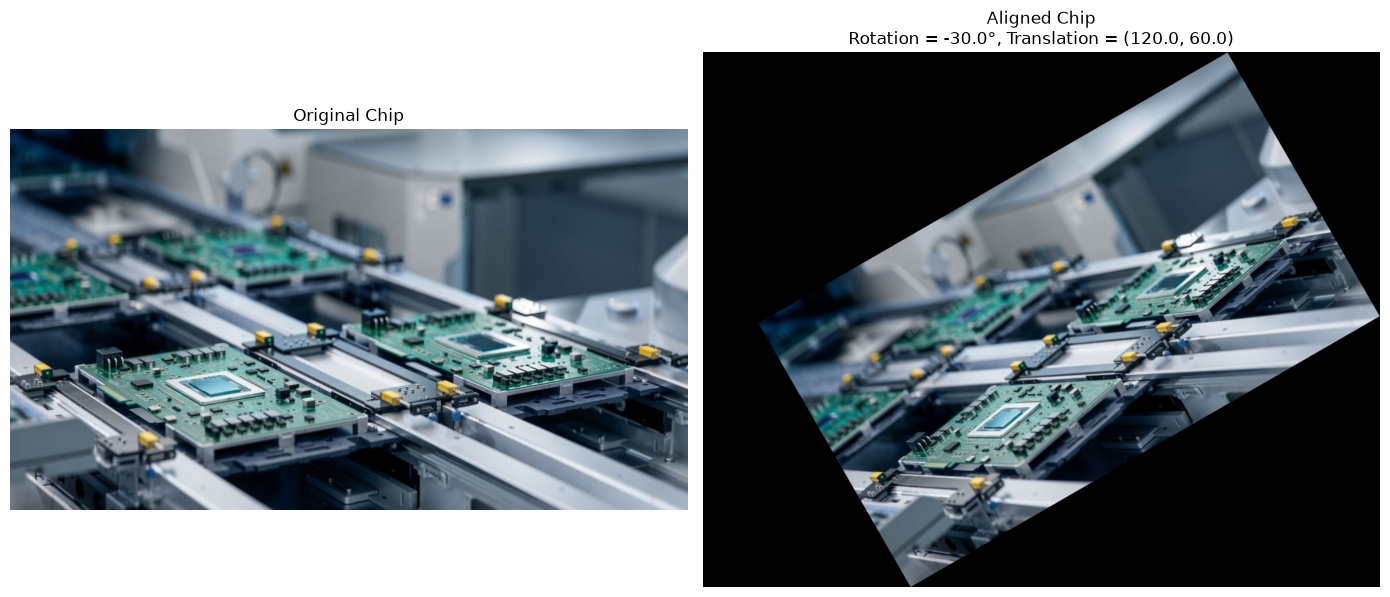

In [1]:
import cv2
import numpy as np
import math
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Input and output files
# ---------------------------------------------------------
image_path = "chip.jpg"
output_path = "task5_aligned_chip.jpg"

# ---------------------------------------------------------
# Transformation parameters
# ---------------------------------------------------------
angle = -30.0       # rotation angle in degrees
tx = 120.0          # translation in x direction
ty = 60.0           # translation in y direction

# ---------------------------------------------------------
# Read image
# ---------------------------------------------------------
img = cv2.imread(image_path)

if img is None:
    raise FileNotFoundError(f"Could not find image: {image_path}")

h, w = img.shape[:2]

print("Original dimensions:", w, "x", h)

# ---------------------------------------------------------
# Convert angle to radians
# ---------------------------------------------------------
theta = math.radians(angle)

c = math.cos(theta)
s = math.sin(theta)

# ---------------------------------------------------------
# 3x3 Rotation Matrix
#
# R = [ cos(theta)  -sin(theta)  0 ]
#     [ sin(theta)   cos(theta)  0 ]
#     [     0            0       1 ]
# ---------------------------------------------------------
R = np.array([
    [c, -s, 0.0],
    [s,  c, 0.0],
    [0.0, 0.0, 1.0]
], dtype=np.float32)

print("\nRotation Matrix R:")
print(R)

# ---------------------------------------------------------
# 3x3 Translation Matrix
#
# T = [ 1  0  tx ]
#     [ 0  1  ty ]
#     [ 0  0   1 ]
# ---------------------------------------------------------
T = np.array([
    [1.0, 0.0, tx],
    [0.0, 1.0, ty],
    [0.0, 0.0, 1.0]
], dtype=np.float32)

print("\nTranslation Matrix T:")
print(T)

# ---------------------------------------------------------
# Combined rigid transformation
#
# M = T @ R
#
# Rotation is performed first, then translation.
# ---------------------------------------------------------
M = T @ R

print("\nCombined rigid matrix T @ R:")
print(M)

# ---------------------------------------------------------
# Calculate a canvas large enough for the rotated image
# ---------------------------------------------------------
corners = np.array([
    [0, 0, 1],
    [w, 0, 1],
    [0, h, 1],
    [w, h, 1]
], dtype=np.float32).T

transformed_corners = M @ corners

x_coords = transformed_corners[0, :]
y_coords = transformed_corners[1, :]

min_x = np.min(x_coords)
max_x = np.max(x_coords)
min_y = np.min(y_coords)
max_y = np.max(y_coords)

# ---------------------------------------------------------
# Shift transformation so all pixels fit inside canvas
# ---------------------------------------------------------
shift_x = -min_x if min_x < 0 else 0
shift_y = -min_y if min_y < 0 else 0

M[0, 2] += shift_x
M[1, 2] += shift_y

new_w = int(math.ceil(max_x + shift_x))
new_h = int(math.ceil(max_y + shift_y))

print("\nNew dimensions:", new_w, "x", new_h)

print("\nFinal transformation matrix:")
print(M)

# ---------------------------------------------------------
# Apply transformation
# ---------------------------------------------------------
result = cv2.warpPerspective(
    img,
    M,
    (new_w, new_h)
)

# ---------------------------------------------------------
# Save result
# ---------------------------------------------------------
cv2.imwrite(output_path, result)

print("\nSaved:", output_path)

# ---------------------------------------------------------
# Convert BGR to RGB for Matplotlib
# ---------------------------------------------------------
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

# ---------------------------------------------------------
# Display original and transformed image in Jupyter
# ---------------------------------------------------------
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Chip")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result_rgb)
plt.title(f"Aligned Chip\nRotation = {angle}°, Translation = ({tx}, {ty})")
plt.axis("off")

plt.tight_layout()
plt.show()
